<a href="https://colab.research.google.com/github/Thasli-ma-2004/Data-Analytics-using-Python-Project/blob/main/Internship_day_7%2C8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

data={
    'Name':['John','Mary','John'],
    'Sales':[1000,1500,1000]
}

df = pd.DataFrame(data)

print(df.duplicated())

0    False
1    False
2     True
dtype: bool


In [ ]:
import pandas as pd

data={
    'Name':['John','Mary','John'],
    'Sales':[1000,1500,1000]
}

df = pd.DataFrame(data)

df= df.drop_duplicates()

print(df)

   Name  Sales
0  John   1000
1  Mary   1500


In [ ]:
import pandas as pd

data={
    'emp_nm':['John','Mary','John'],
    'emp_sal':[1000,1500,1000]
}

df = pd.DataFrame(data)

df.rename(columns={
    'emp_nm':'Employee Name',
    'emp_sal':'Employee Salary'
    },inplace=True)

print(df)

  Employee Name  Employee Salary
0          John             1000
1          Mary             1500
2          John             1000


In [ ]:
#clean a messy Sales Data Set
import pandas as pd

data={
    'Order_ID':[101,102,103,104,105,106,107,108],
    'Date': ['2025-01-01','2025-01-02','2025-01-03','2025-01-04','2025-01-05','2025-01-06','','2025-01-07'],
    'Product':['Laptop','Mobile','Tablet','Laptop','Monitor','Tablet','Mobile','Monitor'],
    'Sales':[50000,800,1500,700,'',52000,'',1800]
}
df=pd.DataFrame(data)
print("Original Dataset")
print(df)

df=df.drop_duplicates()

df=df.replace('',pd.NA)

df['Sales']=df['Sales'].fillna(0)

df['Date']=df['Date'].fillna('Not Available')

df=df.dropna(subset=['Date'])

print("\nCleaned Dataset")
print(df)




Original Dataset
   Order_ID        Date  Product  Sales
0       101  2025-01-01   Laptop  50000
1       102  2025-01-02   Mobile    800
2       103  2025-01-03   Tablet   1500
3       104  2025-01-04   Laptop    700
4       105  2025-01-05  Monitor       
5       106  2025-01-06   Tablet  52000
6       107               Mobile       
7       108  2025-01-07  Monitor   1800

Cleaned Dataset
   Order_ID           Date  Product  Sales
0       101     2025-01-01   Laptop  50000
1       102     2025-01-02   Mobile    800
2       103     2025-01-03   Tablet   1500
3       104     2025-01-04   Laptop    700
4       105     2025-01-05  Monitor      0
5       106     2025-01-06   Tablet  52000
6       107  Not Available   Mobile      0
7       108     2025-01-07  Monitor   1800


/tmp/ipykernel_4913/2853877141.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sales']=df['Sales'].fillna(0)


In [ ]:
import pandas as pd

data={
    "Region":["South","North","East","West","South","North"],
    "Product":["Laptop","Mobile","Laptop","Tablet","Mobile","Tablet"],
    "Sales":[50000,30000,45000,25000,20000,35000]
}

df = pd.DataFrame(data)

print(df)

  Region Product  Sales
0  South  Laptop  50000
1  North  Mobile  30000
2   East  Laptop  45000
3   West  Tablet  25000
4  South  Mobile  20000
5  North  Tablet  35000


In [ ]:
south_sales = df[df["Region"]=="South"]
print(south_sales)

  Region Product  Sales
0  South  Laptop  50000
4  South  Mobile  20000


In [ ]:
high_sales = df[df["Sales"]>30000]
print(high_sales)

  Region Product  Sales
0  South  Laptop  50000
2   East  Laptop  45000
5  North  Tablet  35000


In [ ]:
sorted_df=df.sort_values("Sales")

print(sorted_df)

  Region Product  Sales
4  South  Mobile  20000
3   West  Tablet  25000
1  North  Mobile  30000
5  North  Tablet  35000
2   East  Laptop  45000
0  South  Laptop  50000


In [ ]:
import pandas as pd

data={
    "Region":["South","North","East","West","South","North"],
    "Product":["Laptop","Mobile","Laptop","Tablet","Mobile","Tablet"],
    "Sales":[50000,30000,45000,25000,20000,35000]
}

df = pd.DataFrame(data)

region_sales=df.groupby("Region")["Sales"].sum()

print(region_sales)

Region
East     45000
North    65000
South    70000
West     25000
Name: Sales, dtype: int64


In [ ]:
product_sales=df.groupby("Product")["Sales"].sum()

print(product_sales)

Product
Laptop    95000
Mobile    50000
Tablet    60000
Name: Sales, dtype: int64


In [ ]:
print(df["Sales"].sum())

205000


In [ ]:
print(df["Sales"].mean())

34166.666666666664


In [ ]:
print(df["Sales"].max())

50000


In [ ]:
print(df["Sales"].min())

20000


In [ ]:
print(df["Sales"].count())

6


In [ ]:
result=df.groupby("Region")["Sales"].agg(
    ["sum","mean","max","min"]
)

print(result)

          sum     mean    max    min
Region                              
East    45000  45000.0  45000  45000
North   65000  32500.0  35000  30000
South   70000  35000.0  50000  20000
West    25000  25000.0  25000  25000


In [ ]:
#Practice: Region-Wise Sales Report

import pandas as pd

data = {
    'OrderID': [101, 102, 103, 104, 105, 106, 107, 108],
    'Region': ['North', 'South', 'North', 'East', 'West', 'South', 'East', 'West'],
    'Product': ['Laptop', 'Mouse', 'Keyboard', 'Laptop', 'Mouse', 'Laptop', 'Keyboard', 'Laptop'],
    'Sales': [50000, 800, 1500, 45000, 900, 55000, 2000, 48000]
}

df = pd.DataFrame(data)

df_active = df[df['Sales'] > 0]

df_sorted = df_active.sort_values(
    by=['Region', 'Sales'],
    ascending=[True, False]
)

report = df_sorted.groupby('Region')['Sales'].agg(
    ['sum', 'mean', 'count']
)

# Rename Columns
report.columns = ['Total Sales', 'Avg Sale', 'Order Count']

print(report)

        Total Sales  Avg Sale  Order Count
Region                                    
East          47000   23500.0            2
North         51500   25750.0            2
South         55800   27900.0            2
West          48900   24450.0            2


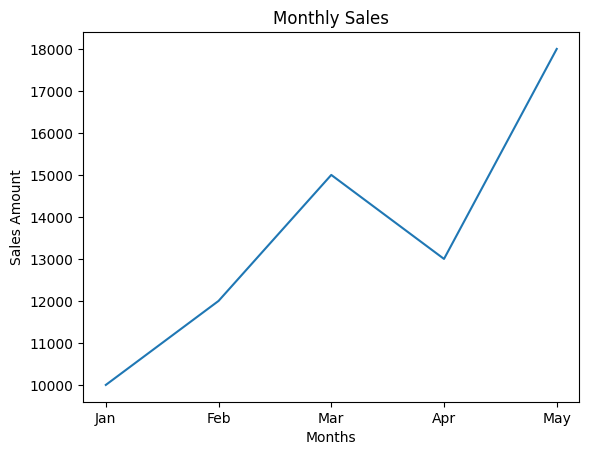

In [ ]:
import matplotlib.pyplot as plt

months=["Jan","Feb","Mar","Apr","May"]
sales=[10000,12000,15000,13000,18000]

plt.plot(months,sales)
plt.xlabel("Months")
plt.ylabel("Sales Amount")
plt.title("Monthly Sales")
plt.show()

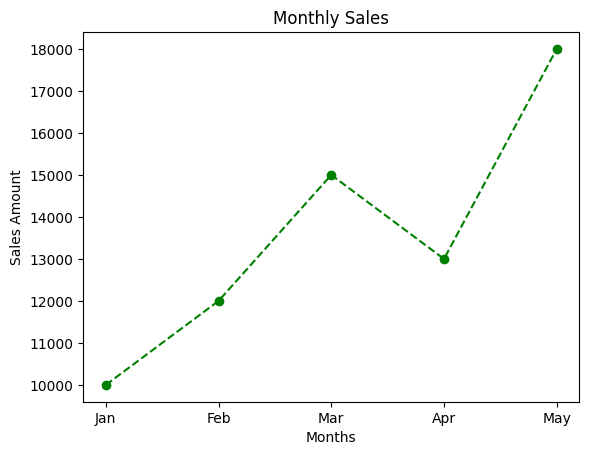

In [ ]:
import matplotlib.pyplot as plt

months=["Jan","Feb","Mar","Apr","May"]
sales=[10000,12000,15000,13000,18000]

plt.plot(months,sales,
         color="green",
         marker="o",
         linestyle="--")
plt.xlabel("Months")
plt.ylabel("Sales Amount")
plt.title("Monthly Sales")
plt.show()

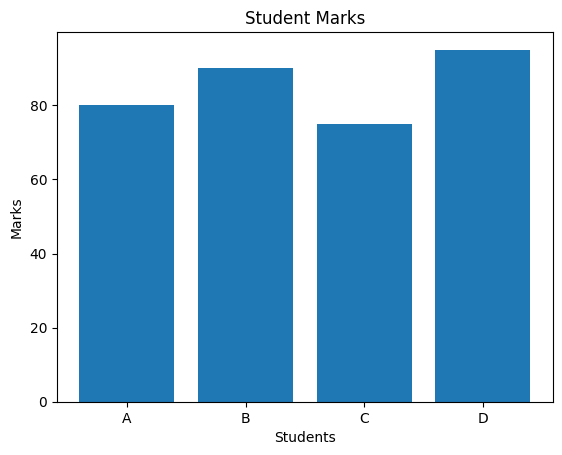

In [ ]:
import matplotlib.pyplot as plt

students=["A","B","C","D"]

marks=[80,90,75,95]

plt.bar(students,marks)
plt.xlabel("Students")
plt.ylabel("Marks")
plt.title("Student Marks")
plt.show()